<a href="https://colab.research.google.com/github/RAGHAVJINDGER/Exploratory-Data-Analysis/blob/main/Experiment9_06-10-26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
from google.colab import files

uploaded = files.upload()

Saving mnist_test.csv to mnist_test.csv
Saving mnist_train.csv to mnist_train.csv


In [3]:
train_df = pd.read_csv("mnist_train.csv")
test_df = pd.read_csv("mnist_test.csv")

In [4]:
print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape:", test_df.shape)

print("\nFirst 5 rows:")
display(train_df.head())

Training Dataset Shape: (3259, 785)
Testing Dataset Shape: (703, 785)

First 5 rows:


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
X_train = train_df.drop("label", axis=1)
y_train = train_df["label"]

X_test = test_df.drop("label", axis=1)
y_test = test_df["label"]

In [6]:
X_train = X_train.values
y_train = y_train.values

X_test = X_test.values
y_test = y_test.values

In [7]:
print("Number of training samples:", X_train.shape[0])
print("Number of testing samples:", X_test.shape[0])

print("Number of features:", X_train.shape[1])

print("Number of classes:", len(np.unique(y_train)))

print("Classes:", np.unique(y_train))

print("Image dimensions: 28 × 28 pixels")

Number of training samples: 3259
Number of testing samples: 703
Number of features: 784
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
Image dimensions: 28 × 28 pixels


In [8]:
unique_labels, label_count = np.unique(
    y_train,
    return_counts=True
)

print("Unique labels:", unique_labels)
print("\nNumber of samples per label:")

for label, count in zip(unique_labels, label_count):
    print(f"{label}: {count}")

Unique labels: [0 1 2 3 4 5 6 7 8 9]

Number of samples per label:
0: 309
1: 363
2: 326
3: 318
4: 357
5: 292
6: 328
7: 356
8: 294
9: 316


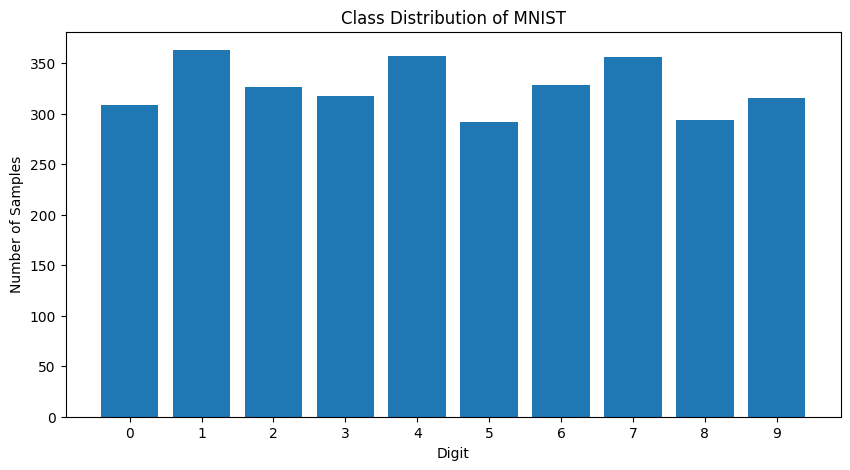

In [9]:
plt.figure(figsize=(10, 5))

plt.bar(unique_labels, label_count)

plt.xlabel("Digit")
plt.ylabel("Number of Samples")
plt.title("Class Distribution of MNIST")

plt.xticks(unique_labels)

plt.show()

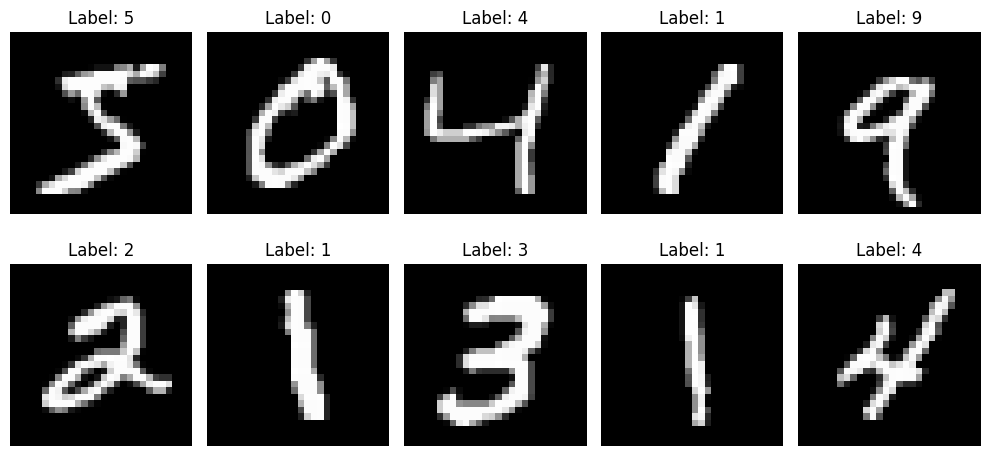

In [10]:
plt.figure(figsize=(10, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    image = X_train[i].reshape(28, 28)

    plt.imshow(image, cmap="gray")

    plt.title(f"Label: {y_train[i]}")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [12]:
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [13]:
pca_all = PCA()

pca_all.fit(X_train)

explained_variance = pca_all.explained_variance_ratio_

print("Total number of principal components:",
      len(explained_variance))

Total number of principal components: 784


In [14]:
for i, variance in enumerate(explained_variance[:20]):

    print(
        f"PC{i+1}: "
        f"{variance:.6f} "
        f"({variance*100:.4f}%)"
    )

PC1: 0.098184 (9.8184%)
PC2: 0.073302 (7.3302%)
PC3: 0.064433 (6.4433%)
PC4: 0.054230 (5.4230%)
PC5: 0.047863 (4.7863%)
PC6: 0.044838 (4.4838%)
PC7: 0.033561 (3.3561%)
PC8: 0.029574 (2.9574%)
PC9: 0.028366 (2.8366%)
PC10: 0.023040 (2.3040%)
PC11: 0.021389 (2.1389%)
PC12: 0.020060 (2.0060%)
PC13: 0.017003 (1.7003%)
PC14: 0.016750 (1.6750%)
PC15: 0.016435 (1.6435%)
PC16: 0.015235 (1.5235%)
PC17: 0.012806 (1.2806%)
PC18: 0.012250 (1.2250%)
PC19: 0.011694 (1.1694%)
PC20: 0.011501 (1.1501%)


In [15]:
variance_table = pd.DataFrame({

    "Principal Component":
        np.arange(1, len(explained_variance) + 1),

    "Explained Variance":
        explained_variance,

    "Explained Variance (%)":
        explained_variance * 100
})

display(variance_table.head(20))

,Principal Component,Explained Variance,Explained Variance (%)
0,1,0.098184,9.818418
1,2,0.073302,7.330209
2,3,0.064433,6.443278
3,4,0.054230,5.422998
4,5,0.047863,4.786340
5,6,0.044838,4.483826
6,7,0.033561,3.356081
7,8,0.029574,2.957432
8,9,0.028366,2.836609
9,10,0.023040,2.303997


In [16]:
cumulative_variance = np.cumsum(
    explained_variance
)

print("Cumulative variance calculated successfully.")

Cumulative variance calculated successfully.


In [17]:
n_90 = np.argmax(
    cumulative_variance >= 0.90
) + 1

n_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

n_99 = np.argmax(
    cumulative_variance >= 0.99
) + 1

print("Components required for 90% variance:", n_90)
print("Components required for 95% variance:", n_95)
print("Components required for 99% variance:", n_99)

Components required for 90% variance: 83
Components required for 95% variance: 145
Components required for 99% variance: 314


In [18]:
variance_summary = pd.DataFrame({

    "Variance Retained": [
        "90%",
        "95%",
        "99%"
    ],

    "Number of Components": [
        n_90,
        n_95,
        n_99
    ]
})

display(variance_summary)

,Variance Retained,Number of Components
0,90%,83
1,95%,145
2,99%,314


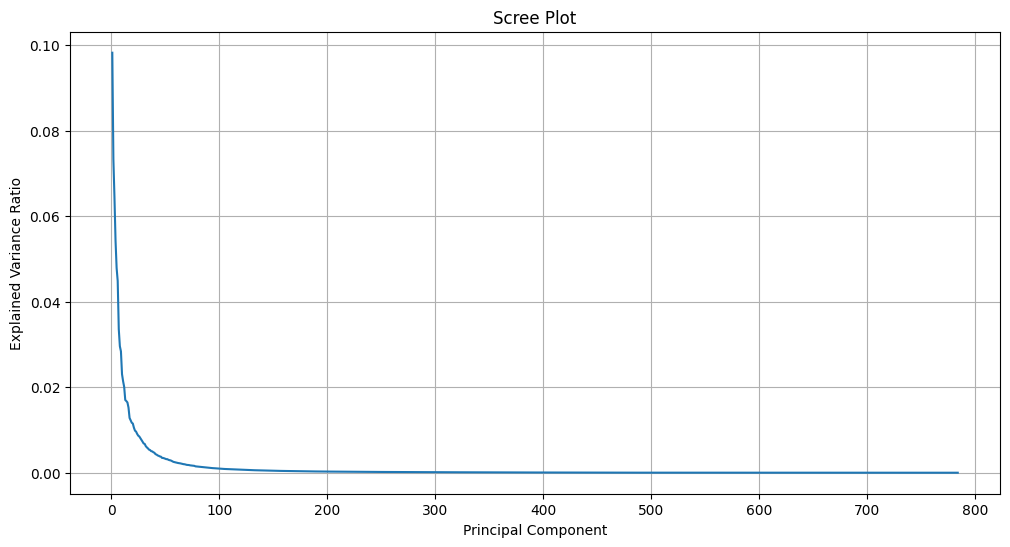

In [19]:
plt.figure(figsize=(12, 6))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")

plt.title("Scree Plot")

plt.grid()

plt.show()

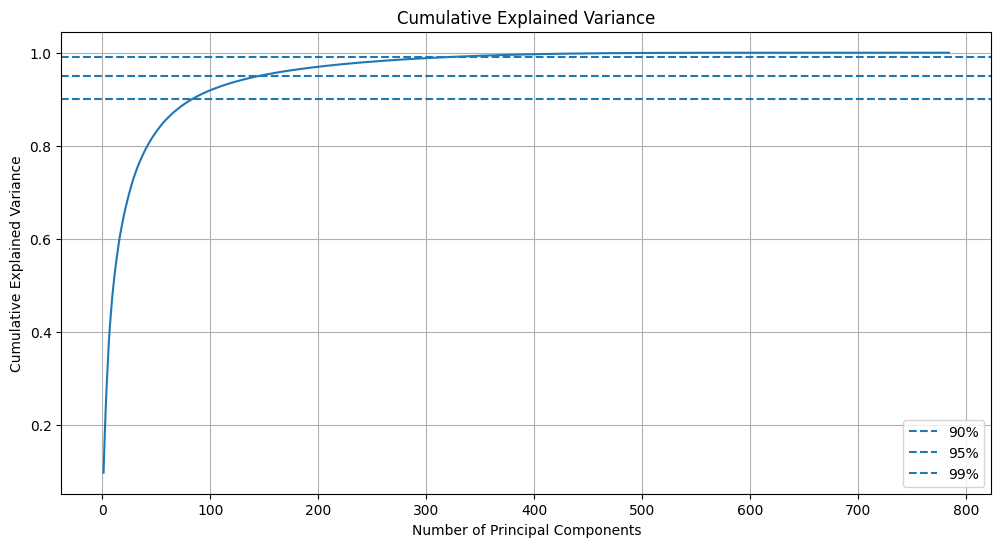

In [20]:
plt.figure(figsize=(12, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance
)

plt.axhline(
    0.90,
    linestyle="--",
    label="90%"
)

plt.axhline(
    0.95,
    linestyle="--",
    label="95%"
)

plt.axhline(
    0.99,
    linestyle="--",
    label="99%"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")

plt.title(
    "Cumulative Explained Variance"
)

plt.legend()
plt.grid()

plt.show()

In [21]:
pca_2 = PCA(n_components=2)

X_train_pca2 = pca_2.fit_transform(X_train)

X_test_pca2 = pca_2.transform(X_test)

print("Original dimensions:",
      X_train.shape[1])

print("PCA dimensions:",
      X_train_pca2.shape[1])

Original dimensions: 784
PCA dimensions: 2


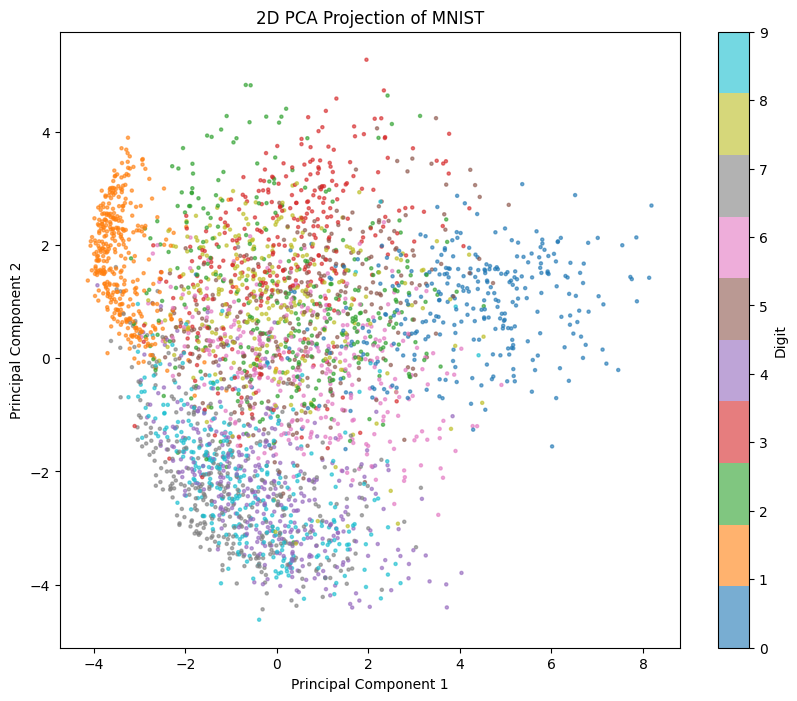

In [22]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(

    X_train_pca2[:, 0],

    X_train_pca2[:, 1],

    c=y_train,

    cmap="tab10",

    s=5,

    alpha=0.6
)

plt.colorbar(
    scatter,
    label="Digit"
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title(
    "2D PCA Projection of MNIST"
)

plt.show()

In [23]:
pca_50 = PCA(n_components=50)

X_train_pca = pca_50.fit_transform(X_train)

X_test_pca = pca_50.transform(X_test)

print("Original training shape:",
      X_train.shape)

print("PCA training shape:",
      X_train_pca.shape)

print("Original testing shape:",
      X_test.shape)

print("PCA testing shape:",
      X_test_pca.shape)

Original training shape: (3259, 784)
PCA training shape: (3259, 50)
Original testing shape: (703, 784)
PCA testing shape: (703, 50)


In [24]:
variance_50 = np.sum(
    pca_50.explained_variance_ratio_
)

print(
    f"Variance retained by 50 components: "
    f"{variance_50:.4f}"
)

print(
    f"Percentage of variance retained: "
    f"{variance_50*100:.2f}%"
)

Variance retained by 50 components: 0.8310
Percentage of variance retained: 83.10%


NameError: name 'X_train_pca_recon' is not defined

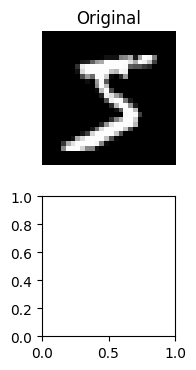

In [25]:
plt.figure(figsize=(10, 4))

for i in range(5):

    # Original
    plt.subplot(2, 5, i + 1)

    plt.imshow(
        X_train[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title("Original")

    plt.axis("off")

    # Reconstructed
    plt.subplot(2, 5, i + 6)

    plt.imshow(
        X_train_pca_recon[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title("Reconstructed")

    plt.axis("off")

plt.tight_layout()

plt.show()

In [26]:
sample_size = 10000

X_tsne_original = X_train[:sample_size]

X_tsne_pca = X_train_pca[:sample_size]

y_tsne = y_train[:sample_size]

print(
    "Samples used for t-SNE:",
    sample_size
)

Samples used for t-SNE: 10000


In [27]:
start_time = time.time()

tsne_original = TSNE(

    n_components=2,

    perplexity=30,

    random_state=42,

    init="random"
)

X_tsne_original_result = (
    tsne_original.fit_transform(
        X_tsne_original
    )
)

tsne_original_time = (
    time.time() - start_time
)

print(
    "t-SNE original data time:",
    tsne_original_time,
    "seconds"
)

t-SNE original data time: 54.54712772369385 seconds


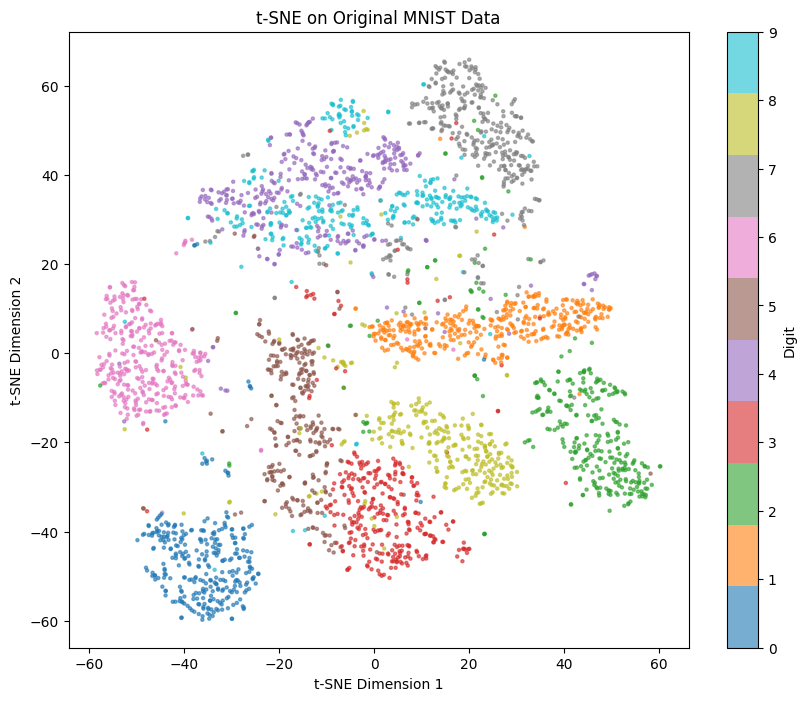

In [28]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(

    X_tsne_original_result[:, 0],

    X_tsne_original_result[:, 1],

    c=y_tsne,

    cmap="tab10",

    s=5,

    alpha=0.6
)

plt.colorbar(
    scatter,
    label="Digit"
)

plt.xlabel("t-SNE Dimension 1")

plt.ylabel("t-SNE Dimension 2")

plt.title(
    "t-SNE on Original MNIST Data"
)

plt.show()

In [29]:
start_time = time.time()

tsne_pca = TSNE(

    n_components=2,

    perplexity=30,

    random_state=42,

    init="random"
)

X_tsne_pca_result = (
    tsne_pca.fit_transform(
        X_tsne_pca
    )
)

tsne_pca_time = (
    time.time() - start_time
)

print(
    "PCA + t-SNE time:",
    tsne_pca_time,
    "seconds"
)

PCA + t-SNE time: 53.2116117477417 seconds


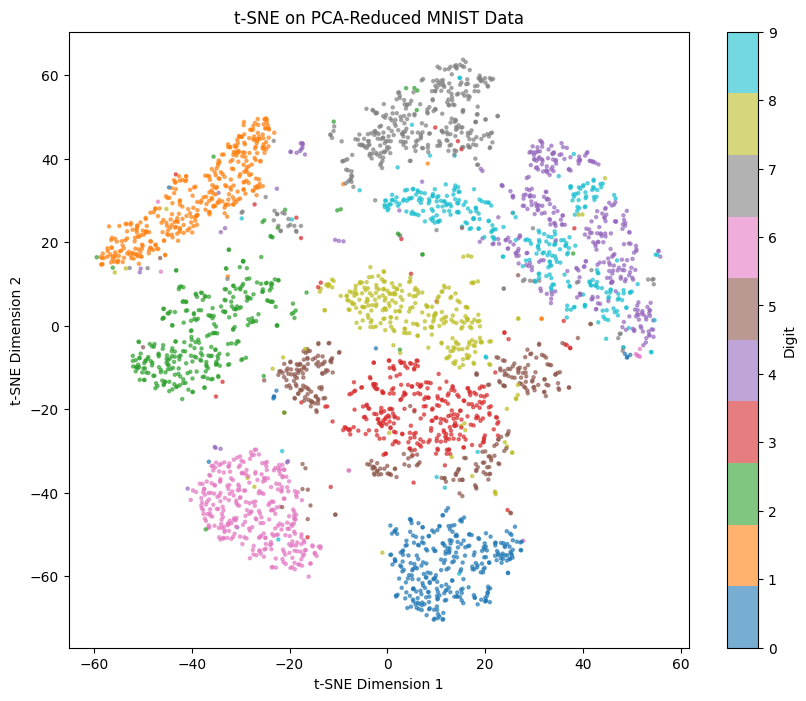

In [30]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(

    X_tsne_pca_result[:, 0],

    X_tsne_pca_result[:, 1],

    c=y_tsne,

    cmap="tab10",

    s=5,

    alpha=0.6
)

plt.colorbar(
    scatter,
    label="Digit"
)

plt.xlabel("t-SNE Dimension 1")

plt.ylabel("t-SNE Dimension 2")

plt.title(
    "t-SNE on PCA-Reduced MNIST Data"
)

plt.show()


Running t-SNE with perplexity = 5


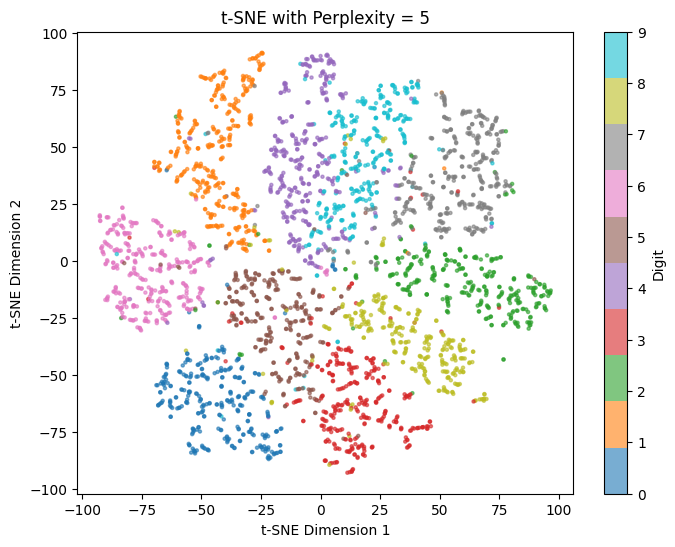

Running t-SNE with perplexity = 30


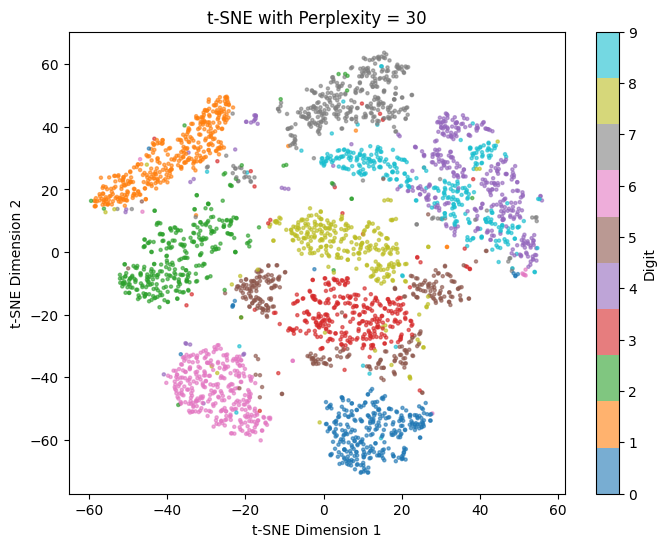

Running t-SNE with perplexity = 50


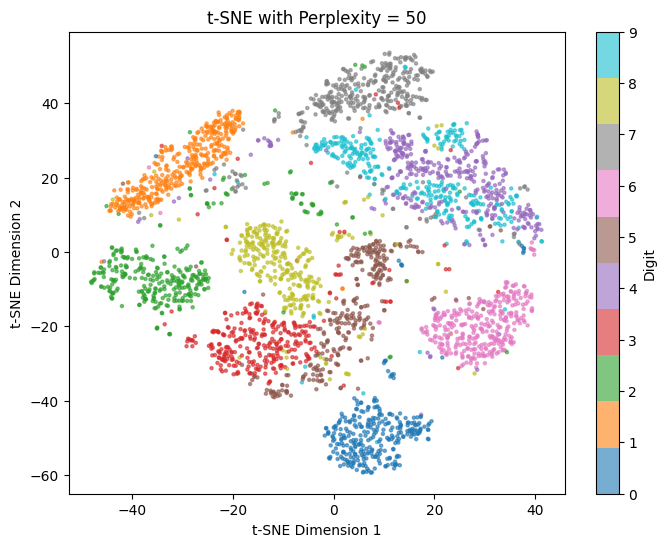

In [31]:
perplexities = [5, 30, 50]

for perplexity in perplexities:

    print(
        f"Running t-SNE "
        f"with perplexity = {perplexity}"
    )

    tsne = TSNE(

        n_components=2,

        perplexity=perplexity,

        random_state=42,

        init="random"
    )

    X_tsne_temp = tsne.fit_transform(
        X_tsne_pca
    )

    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(

        X_tsne_temp[:, 0],

        X_tsne_temp[:, 1],

        c=y_tsne,

        cmap="tab10",

        s=5,

        alpha=0.6
    )

    plt.colorbar(
        scatter,
        label="Digit"
    )

    plt.xlabel("t-SNE Dimension 1")

    plt.ylabel("t-SNE Dimension 2")

    plt.title(
        f"t-SNE with Perplexity = {perplexity}"
    )

    plt.show()

In [32]:
print(
    "Training KNN using ORIGINAL data..."
)

start_train = time.time()

knn_original = KNeighborsClassifier(
    n_neighbors=5
)

knn_original.fit(
    X_train,
    y_train
)

training_time_original = (
    time.time() - start_train
)

print(
    "Training completed."
)

Training KNN using ORIGINAL data...
Training completed.


In [33]:
start_prediction = time.time()

y_pred_original = (
    knn_original.predict(X_test)
)

prediction_time_original = (
    time.time() - start_prediction
)

accuracy_original = accuracy_score(
    y_test,
    y_pred_original
)

print(
    "Original Data Accuracy:",
    accuracy_original
)

print(
    "Original Training Time:",
    training_time_original,
    "seconds"
)

print(
    "Original Prediction Time:",
    prediction_time_original,
    "seconds"
)

Original Data Accuracy: 0.8862019914651493
Original Training Time: 0.0264892578125 seconds
Original Prediction Time: 0.32326388359069824 seconds


In [34]:
print(
    "Training KNN using PCA data..."
)

start_train = time.time()

knn_pca = KNeighborsClassifier(
    n_neighbors=5
)

knn_pca.fit(
    X_train_pca,
    y_train
)

training_time_pca = (
    time.time() - start_train
)

print(
    "Training completed."
)

Training KNN using PCA data...
Training completed.


In [35]:
start_prediction = time.time()

y_pred_pca = (
    knn_pca.predict(X_test_pca)
)

prediction_time_pca = (
    time.time() - start_prediction
)

accuracy_pca = accuracy_score(
    y_test,
    y_pred_pca
)

print(
    "PCA Data Accuracy:",
    accuracy_pca
)

print(
    "PCA Training Time:",
    training_time_pca,
    "seconds"
)

print(
    "PCA Prediction Time:",
    prediction_time_pca,
    "seconds"
)

PCA Data Accuracy: 0.914651493598862
PCA Training Time: 0.002234220504760742 seconds
PCA Prediction Time: 0.05535626411437988 seconds


In [36]:
results = pd.DataFrame({

    "Method": [
        "Original 784D",
        "PCA 50D"
    ],

    "Dimensions": [
        784,
        50
    ],

    "Accuracy": [
        accuracy_original,
        accuracy_pca
    ],

    "Training Time (sec)": [
        training_time_original,
        training_time_pca
    ],

    "Prediction Time (sec)": [
        prediction_time_original,
        prediction_time_pca
    ],

    "Memory (MB)": [
        X_train.nbytes / (1024**2),
        X_train_pca.nbytes / (1024**2)
    ]
})

display(results)

,Method,Dimensions,Accuracy,Training Time (sec),Prediction Time (sec),Memory (MB)
0,Original 784D,784,0.886202,0.026489,0.323264,9.746765
1,PCA 50D,50,0.914651,0.002234,0.055356,0.621605


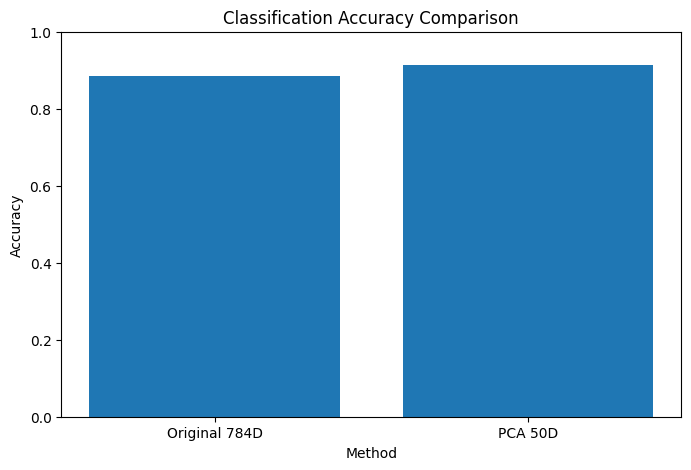

In [37]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Method"],
    results["Accuracy"]
)

plt.xlabel("Method")
plt.ylabel("Accuracy")

plt.title(
    "Classification Accuracy Comparison"
)

plt.ylim(0, 1)

plt.show()

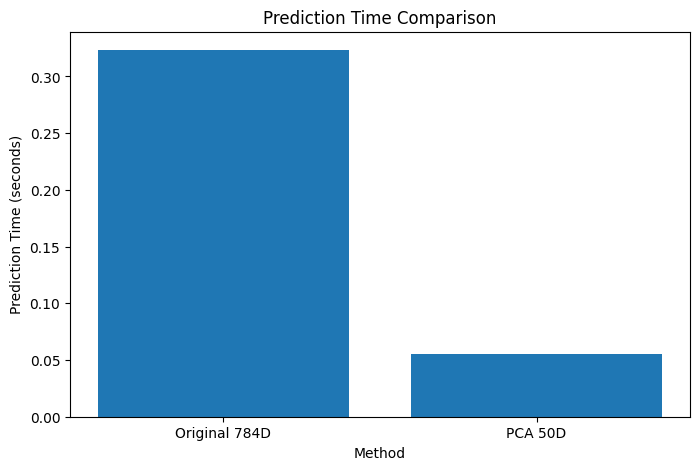

In [38]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Method"],
    results["Prediction Time (sec)"]
)

plt.xlabel("Method")

plt.ylabel(
    "Prediction Time (seconds)"
)

plt.title(
    "Prediction Time Comparison"
)

plt.show()

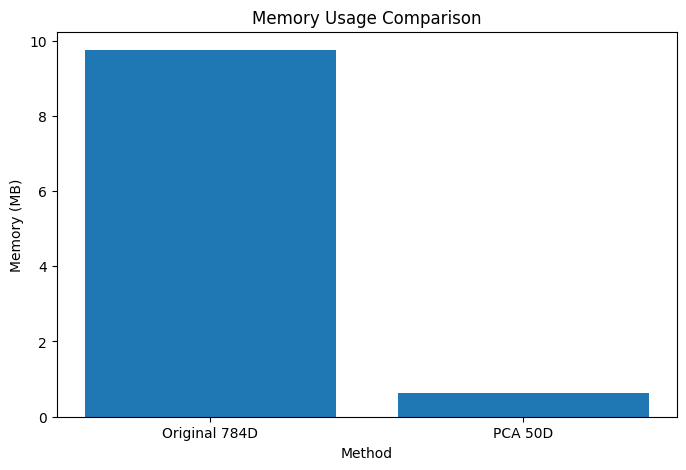

In [39]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Method"],
    results["Memory (MB)"]
)

plt.xlabel("Method")

plt.ylabel("Memory (MB)")

plt.title(
    "Memory Usage Comparison"
)

plt.show()